In [2]:
import json
import re
import matplotlib.pyplot as plt
import numpy as np

In [3]:
result_files = {
    # "Teuken (5274)": "/raid/s3/opengptx/behzad_shomali/evaluation_results/teuken3.7B_IT_LoRA-OpenMathInstruct-2/2025_08_26-09_59_53_4096/checkpoint-5274/results/Behzadshomali/Teuken3.7B_IT_LoRA-OpenMathInstruct-2/results_2025-08-27T02-06-25.078549.json",
    # "Teuken (r=4096 all-linear/lm_head)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.73T_IT_OpenMathInstruct-2/2025_08_26-09_59_53_4096/checkpoint-15823/hf_converted/results_2025-08-27T21-25-05.922917.json",
    # "Teuken (r=1024)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.73T_IT_OpenMathInstruct-2/2025_08_27-20_28_29/rank1024/checkpoint-4666/hf_converted/results_2025-08-28T17-01-19.206805.json",
    # "Teuken (r=512)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.73T_IT_OpenMathInstruct-2/2025_08_28-04_49_19/rank512/checkpoint-4666/lora_merged/results_2025-08-28T21-19-43.752151.json",
    
    "Qwen3-4B-Base": "/raid/s3/opengptx/behzad_shomali/evaluation_results/Qwen/Qwen3-4B-Base/results/Qwen/Qwen3-4B-Base/results_2025-08-29T16-32-56.800414.json",
    # "Qwen3-4B (r=512)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.73T_IT_OpenMathInstruct-2/2025_08_29-12_22_48/rank512/checkpoint-4000/lora_merged/results_2025-08-29T21-20-41.801243.json",    
    "Qwen3-4B (r=8)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.73T_IT_OpenMathInstruct-2/2025_08_30-19_33_56/rank8/checkpoint-9084/lora_merged/results_2025-08-31T13-12-10.894963.json",
    
    "Teuken-Base": "/raid/s3/opengptx/behzad_shomali/evaluation_results/teuken3.7B/results/Behzadshomali/Teuken3.7B/results_2025-08-27T14-52-13.185127.json",
    # "Teuken (less data)(r+=1024)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.73T_IT_OpenMathInstruct-2/2025_08_30-01_31_25/rank1024/checkpoint-4666/lora_merged/results_2025-08-30T12-12-27.249412.json",
    # "Teuken (less data)(r+=512)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.73T_IT_OpenMathInstruct-2/2025_08_30-16_23_44/rank512/checkpoint-4798/lora_merged/results_2025-08-31T18-52-09.829641.json",
    # "Teuken (2000) (r+=16)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.7B_IT_OpenMathInstruct-2/Teuken3.7B_IT_OpenMathInstruct-2/Teuken3.7B_IT_OpenMathInstruct-2/2025_09_02-17_50_17/checkpoint-2000/lora_merged/results_2025-09-03T23-42-48.371387.json",
    # "Teuken (4000) (r+=16)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.7B_IT_OpenMathInstruct-2/Teuken3.7B_IT_OpenMathInstruct-2/Teuken3.7B_IT_OpenMathInstruct-2/2025_09_02-17_50_17/checkpoint-4000/lora_merged/results_2025-09-04T05-23-10.550667.json",
    # "Teuken (2001)(r+=8)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.7B_IT_OpenMathInstruct-2/2025_09_01-11_26_37/checkpoint-2000/lora_merged/results_2025-09-02T03-26-58.773803.json",

    "Teuken (2000)(r+=8)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.7B_IT_OpenMathInstruct-2/2025_09_04-17_30_34/checkpoint-2000/lora_merged/results_2025-09-05T22-55-32.473307.json",
    "Teuken (6000)(r+=8)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.7B_IT_OpenMathInstruct-2/2025_09_04-17_30_34/checkpoint-6000/lora_merged/results_2025-09-06T10-15-56.136425.json",
    "Teuken (7194)(r+=8)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.7B_IT_OpenMathInstruct-2/2025_09_04-17_30_34/checkpoint-7194/lora_merged/results_2025-09-06T15-56-56.192311.json",


    "Teuken (2000) (r+=16)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.7B_IT_OpenMathInstruct-2/Teuken3.7B_IT_OpenMathInstruct-2/Teuken3.7B_IT_OpenMathInstruct-2/2025_09_03-12_21_29/checkpoint-2000/lora_merged/results_2025-09-04T23-23-43.277440.json",
    # "Teuken (4001) (r+=16)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.7B_IT_OpenMathInstruct-2/Teuken3.7B_IT_OpenMathInstruct-2/Teuken3.7B_IT_OpenMathInstruct-2/2025_09_03-12_21_29/checkpoint-4000/lora_merged/results_2025-09-05T05-05-29.268682.json",
    "Teuken (6000) (r+=16)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.7B_IT_OpenMathInstruct-2/Teuken3.7B_IT_OpenMathInstruct-2/Teuken3.7B_IT_OpenMathInstruct-2/2025_09_03-12_21_29/checkpoint-6000/lora_merged/results_2025-09-05T10-46-27.019016.json",
    "Teuken (7194) (r+=16)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.7B_IT_OpenMathInstruct-2/Teuken3.7B_IT_OpenMathInstruct-2/Teuken3.7B_IT_OpenMathInstruct-2/2025_09_03-12_21_29/checkpoint-7194/lora_merged/results_2025-09-05T16-27-29.039891.json",

    "Teuken r+16 (1st phase)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/_lora+_rank16_alpha16_1M_Markus/2025_09_11-18_57_22/checkpoint-20000/lora_merged/results_2025-09-15T17-51-30.638743.json",
    "Teuken r+=16 (multiple phase)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/_lora+_rank16_alpha16_1M_Markus_continue/2025_09_13-17_15_37/checkpoint-20000/lora_merged/results_2025-09-15T12-22-25.252473.json",
    "Teuken r+=16 (LM_head)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/_lora+_rank16_alpha32_1M_lmHead/2025_09_15-12_33_51/checkpoint-16000/lora_merged/results_2025-09-16T12-51-17.447961.json",
    

    "Llama-Base": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/meta-llama/Llama-3.2-3B-base/results/meta-llama/Llama-3.2-3B/results_2025-09-02T10-51-30.022514.json",
    "Llama3.1 (2000) (r+=16)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Llama3.1_3B_IT_OpenMathInstruct-2/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-18_41_56/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-20_53_57/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_02-11_13_11/checkpoint-2000/lora_merged/results_2025-09-02T22-36-29.058284.json",
    "Llama3.1 (4338) (r+=16)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Llama3.1_3B_IT_OpenMathInstruct-2/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-18_41_56/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-20_53_57/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_02-11_13_11/checkpoint-4338/lora_merged/results_2025-09-03T00-12-35.380597.json",
    "Llama3.1 (2000) (r+=8)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-11_04_00/checkpoint-2000/lora_merged/results_2025-09-01T21-37-41.924231.json",
    "Llama3.1 (4000) (r+=8)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-11_04_00/checkpoint-4000/lora_merged/results_2025-09-01T20-15-00.456842.json",
    
}

baseline_paths = {
    "Teuken-Base": "/raid/s3/opengptx/behzad_shomali/evaluation_results/teuken3.7B/results/Behzadshomali/Teuken3.7B/results_2025-08-27T14-52-13.185127.json",
    "Llama-Base": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/meta-llama/Llama-3.2-3B-base/results/meta-llama/Llama-3.2-3B/results_2025-09-02T10-51-30.022514.json",
    "Qwen3-4B-Base": "/raid/s3/opengptx/behzad_shomali/evaluation_results/Qwen/Qwen3-4B-Base/results/Qwen/Qwen3-4B-Base/results_2025-08-29T16-32-56.800414.json",
}

In [4]:
result_files_markus_config = {
    "rank8 (15000)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.7B_IT_OpenMathInstruct-2/2025_09_05-17_02_58_Teuken3.7B_IT_OpenMathInstruct-2/2025_09_06-12_40_07_lora+_rank8_alpha16_1M(Markus)/2025_09_06-12_43_03/checkpoint-15000/lora_merged/results_2025-09-09T01-34-21.068264.json",
    "rank8 (30000)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.7B_IT_OpenMathInstruct-2/2025_09_05-17_02_58_Teuken3.7B_IT_OpenMathInstruct-2/2025_09_06-12_40_07_lora+_rank8_alpha16_1M(Markus)/2025_09_06-12_43_03/checkpoint-30000/lora_merged/results_2025-09-09T07-16-14.041699.json",

    "rank16 (15000)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.7B_IT_OpenMathInstruct-2/2025_09_05-17_03_49_Teuken3.7B_IT_OpenMathInstruct-2/2025_09_06-12_39_29_lora+_rank16_alpha32_1M(Markus)/2025_09_06-12_43_26/checkpoint-15000/lora_merged/results_2025-09-08T22-46-50.827917.json",
    "rank16 (30000)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.7B_IT_OpenMathInstruct-2/2025_09_05-17_03_49_Teuken3.7B_IT_OpenMathInstruct-2/2025_09_06-12_39_29_lora+_rank16_alpha32_1M(Markus)/2025_09_06-12_43_26/checkpoint-30000/lora_merged/results_2025-09-09T01-40-45.148923.json",
    "rank16 (45000)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.7B_IT_OpenMathInstruct-2/2025_09_05-17_03_49_Teuken3.7B_IT_OpenMathInstruct-2/2025_09_06-12_39_29_lora+_rank16_alpha32_1M(Markus)/2025_09_06-12_43_26/checkpoint-45000/lora_merged/results_2025-09-09T04-34-39.933765.json",
    "rank16 (60000)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.7B_IT_OpenMathInstruct-2/2025_09_05-17_03_49_Teuken3.7B_IT_OpenMathInstruct-2/2025_09_06-12_39_29_lora+_rank16_alpha32_1M(Markus)/2025_09_06-12_43_26/checkpoint-60000/lora_merged/results_2025-09-09T07-28-39.436000.json",
    # "rank16 (63294)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.7B_IT_OpenMathInstruct-2/2025_09_05-17_03_49_Teuken3.7B_IT_OpenMathInstruct-2/2025_09_06-12_39_29_lora+_rank16_alpha32_1M(Markus)/2025_09_06-12_43_26/checkpoint-63294/lora_merged/results_2025-09-09T10-22-25.547800.json"
}

In [5]:
def plot_result(
    result_file,
    ax,
    benchmarks_dict,
    legend=None,
    hatch="",
    index=0,
    total=1, 
    color=None,
    baseline_file=None
):
    
    baseline_results_json = json.load(open(baseline_file, "r"))
    baseline_results = {}
    for benchmark, metric in benchmarks_dict.items():
        baseline_results[benchmark] = baseline_results_json["results"][benchmark][metric]
        
    
    results_json = json.load(open(result_file, "r"))
    labels, results, results_stderr, baseline_diffs = [], [], [], []
    for benchmark, metric in benchmarks_dict.items():
        labels.append(benchmark)
        results.append(results_json["results"][benchmark][metric])
        results_stderr.append(results_json["results"][benchmark][f"{metric}_stderr"])
        baseline_diffs.append(results[-1]-baseline_results[benchmark])

    x = np.arange(len(labels))
    bar_width = 0.8 / total
    x_positions = x - 0.4 + index * bar_width + bar_width / 2

    ax.bar(
        x_positions,
        results,
        width=bar_width,
        label=legend,
        alpha=0.6,
        hatch=hatch,
        color=color
    )

    # ax.errorbar(
    #     x_positions,
    #     results,
    #     yerr=results_stderr,
    #     fmt='o',
    #     color=color,
    #     capsize=0.5
    # )

    for xpos, height, diff in zip(x_positions, results, baseline_diffs):
        # diff = height - baseline_results[benchmark]
        ax.text(
            xpos,
            height,  # just above the bar
            f"{diff*100:.0f}",  # format with 2 decimals
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=0
        )

    ax.set_ylabel("Score")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.legend()

    ax.set_yticks(np.linspace(0, 1, 10))
    ax.set_yticklabels(np.arange(0, 100, 10))

    return ax


In [6]:
# benchmarks = {
#     # "leaderboard|arc:challenge|0": "acc_norm",
#     "leaderboard|arc:challenge|5": "acc_norm",
#     "leaderboard|gsm8k|0": "qem",
#     "leaderboard|gsm8k|5": "qem",
#     "leaderboard|hellaswag|0": "acc_norm",
#     "leaderboard|hellaswag|5": "acc_norm",
#     "leaderboard|mmlu:high_school_mathematics|0": "acc",
#     "leaderboard|mmlu:high_school_mathematics|5": "acc",
#     # "leaderboard|truthfulqa:mc|0": "truthfulqa_mc2",
#     "leaderboard|truthfulqa:mc|5": "truthfulqa_mc2"
# }

In [7]:
benchmarks = {
    "leaderboard|arc:challenge|5": "acc_norm",
    "leaderboard|gsm8k|5": "qem",
    "leaderboard|hellaswag|5": "acc_norm",
    "leaderboard|truthfulqa:mc|5": "truthfulqa_mc2"
}

In [8]:
order_benchmarks_for_latex = [
    'leaderboard|arc:challenge|5',
    'leaderboard|gsm8k|5',
    'leaderboard|hellaswag|5',
    'leaderboard|truthfulqa:mc|5'
]

baseline_results = {}
for value, path in (baseline_paths | result_files).items():
    results_json = json.load(open(path, "r"))
    for benchmark, metric in benchmarks.items():
        baseline_results[benchmark] = results_json["results"][benchmark][metric]

    print("="*20, value, "="*20)
    for benchmark in order_benchmarks_for_latex:
        print(f"{baseline_results[benchmark]:.4f} & ", end="")
    print("\n\n")

==================== Teuken-Base ====================
0.5435 & 0.1001 & 0.7765 & 0.4659 & 


==================== Llama-Base ====================
0.4949 & 0.2661 & 0.7588 & 0.4737 & 


==================== Qwen3-4B-Base ====================
0.5350 & 0.8264 & 0.7394 & 0.5530 & 


==================== Qwen3-4B (r=8) ====================
0.5853 & 0.0212 & 0.7373 & 0.5200 & 


==================== Teuken (2000)(r+=8) ====================
0.4727 & 0.1008 & 0.7392 & 0.4797 & 


==================== Teuken (6000)(r+=8) ====================
0.4701 & 0.0917 & 0.7375 & 0.4722 & 


==================== Teuken (7194)(r+=8) ====================
0.4710 & 0.0857 & 0.7378 & 0.4723 & 


==================== Teuken (2000) (r+=16) ====================
0.4693 & 0.0371 & 0.7348 & 0.4637 & 


==================== Teuken (6000) (r+=16) ====================
0.4608 & 0.0660 & 0.7333 & 0.4531 & 


==================== Teuken (7194) (r+=16) ====================
0.4608 & 0.0728 & 0.7341 & 0.4568 & 


============

In [9]:
baseline_results

{'leaderboard|arc:challenge|5': 0.45051194539249145,
 'leaderboard|gsm8k|5': 0.4306292645943897,
 'leaderboard|hellaswag|5': 0.7317267476598287,
 'leaderboard|truthfulqa:mc|5': 0.4476620845105897}

In [10]:
colors = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # green
    "#D55E00",  # red
    "#CC79A7",  # pink
    "#F0E442",  # yellow
    "#56B4E9",  # light blue
    "#999999"   # gray
]
patterns = [ "", "/" , "\\" , "|" , "-" , "+" , "x", "o", "O", ".", "*" ]

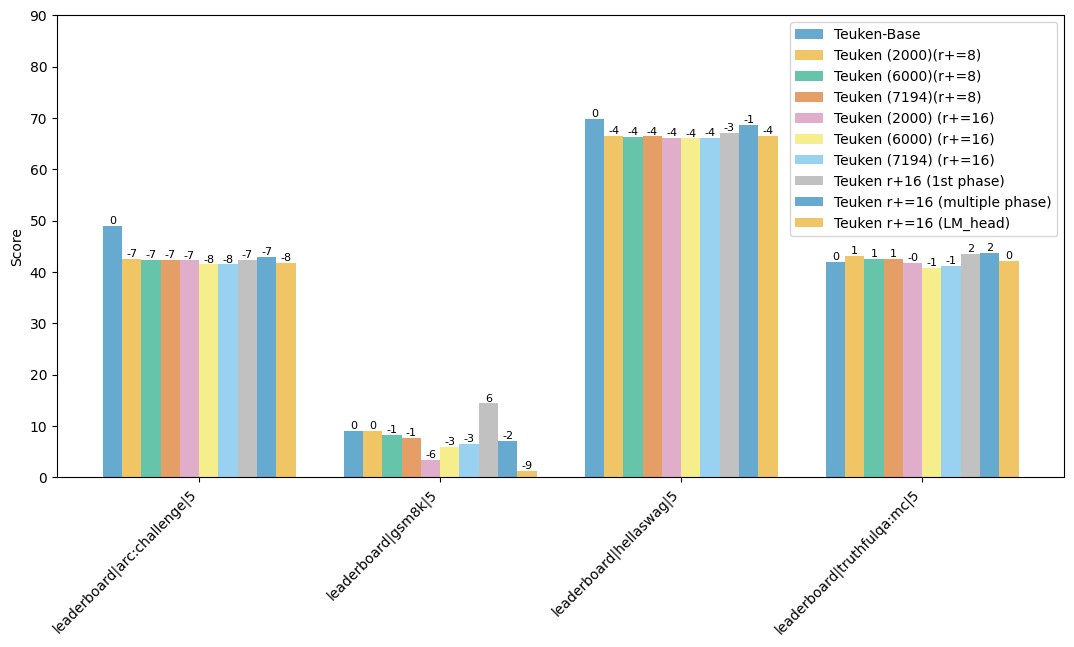

In [11]:

fig, ax = plt.subplots(figsize=(13, 6))

index = 0
results_dict = {}
sub_results = {legend: result for legend, result in result_files.items() if "teuken" in legend.lower()}
for legend, result_file in sub_results.items():

    hatch = patterns[0]
    color = colors[index % len(colors)]
    ax = plot_result(result_file, ax, benchmarks, legend, hatch, index=index, total=len(sub_results), color=color, baseline_file=baseline_paths['Teuken-Base'])
    index += 1

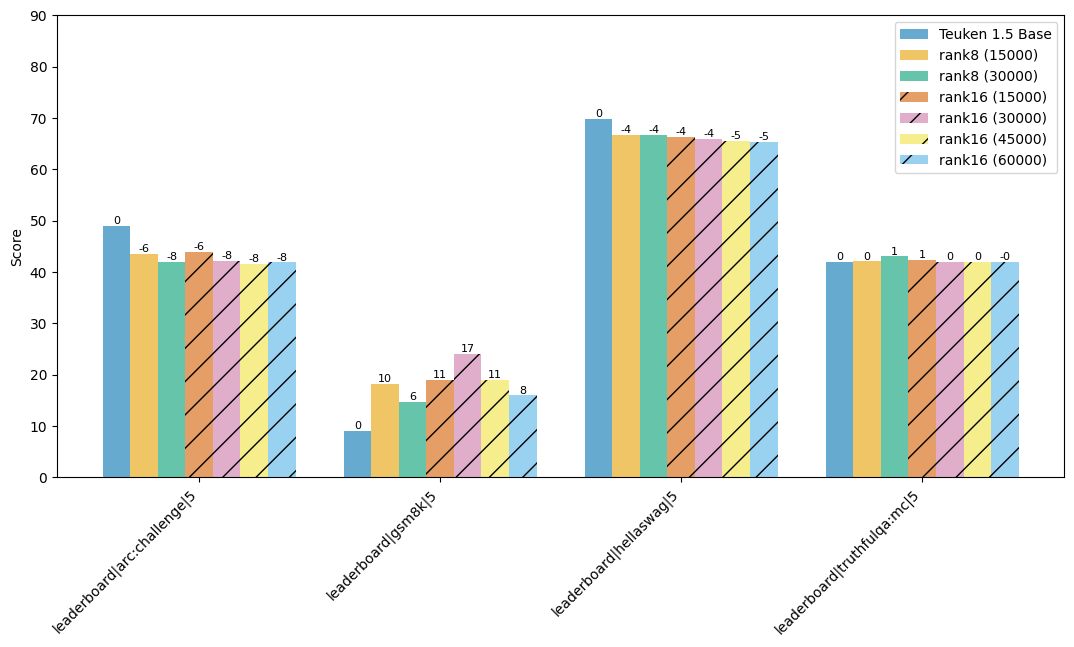

In [21]:

fig, ax = plt.subplots(figsize=(13, 6))

index = 0
results_dict = {}
sub_results = {'Teuken 1.5 Base': baseline_paths['Teuken-Base']} | result_files_markus_config
for legend, result_file in sub_results.items():

    hatch = patterns[0]
    if "rank16" in legend.lower():
        hatch = patterns[1]
    color = colors[index % len(colors)]
    ax = plot_result(result_file, ax, benchmarks, legend, hatch, index=index, total=len(sub_results), color=color, baseline_file=baseline_paths['Teuken-Base'])
    index += 1

In [ ]:

fig, ax = plt.subplots(figsize=(13, 6))

index = 0
results_dict = {}
sub_results = {legend: result for legend, result in result_files.items() if "teuken" in legend.lower()}
for legend, result_file in sub_results.items():

    hatch = patterns[0]
    color = colors[index % len(colors)]
    ax = plot_result(result_file, ax, benchmarks, legend, hatch, index=index, total=len(sub_results), color=color, baseline_file=baseline_paths['Teuken-Base'])
    index += 1

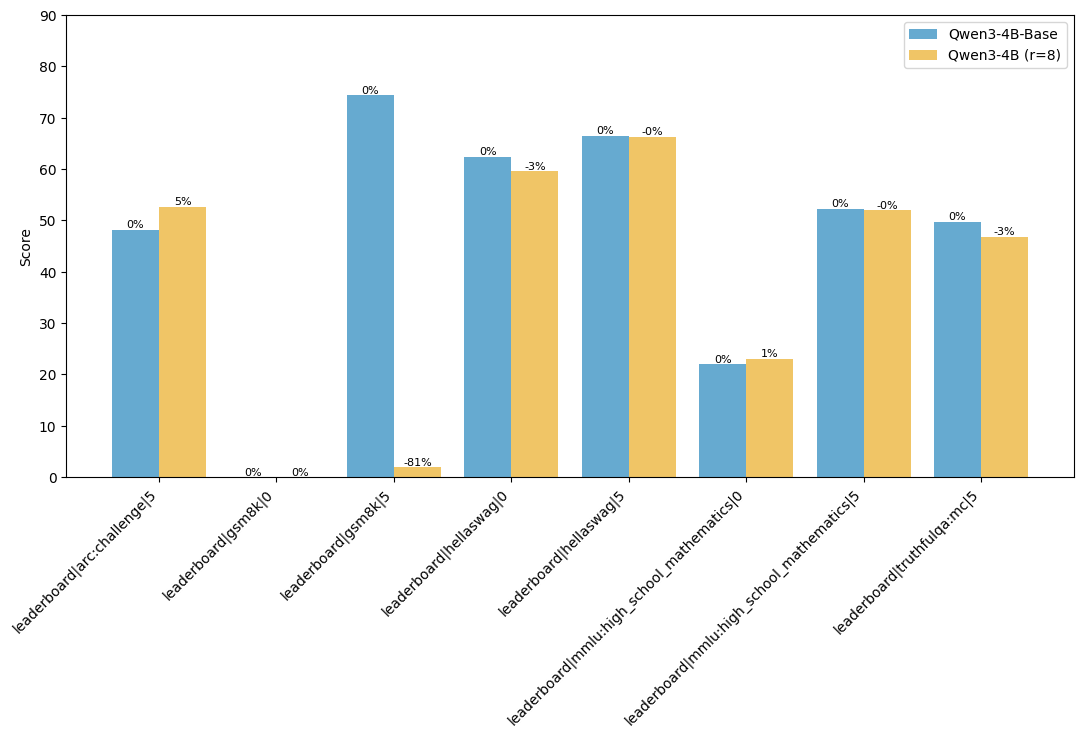

In [17]:

fig, ax = plt.subplots(figsize=(13, 6))

index = 0
sub_results = {legend: result for legend, result in result_files.items() if "qwen" in legend.lower()}
baseline_diffs = {}

for legend, result_file in sub_results.items():
    hatch = patterns[0]
    color = colors[index]
    ax = plot_result(result_file, ax, benchmarks, legend, hatch, index=index, total=len(sub_results), color=color, baseline_file=baseline_paths['Qwen3-4B-Base'])
    index += 1

In [ ]:
base_line

'/raid/s3/opengptx/behzad_shomali/instruction_tuning/meta-llama/Llama-3.2-3B-base/results/meta-llama/Llama-3.2-3B/results_2025-09-02T10-51-30.022514.json'

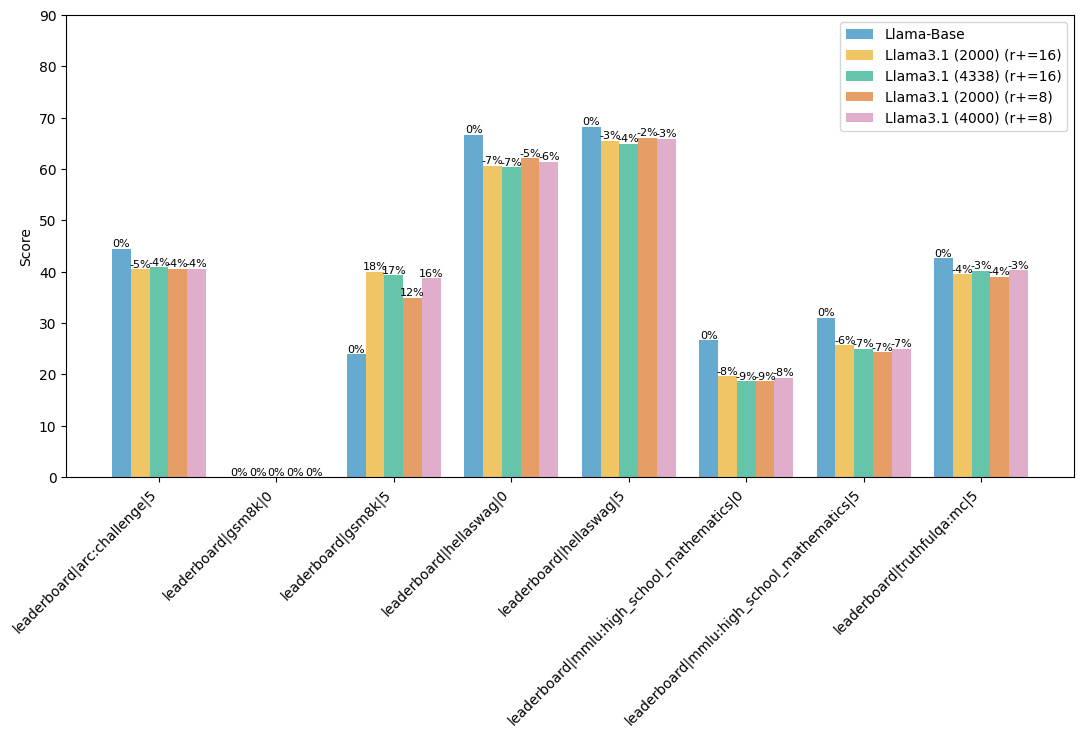

In [9]:

fig, ax = plt.subplots(figsize=(13, 6))

index = 0
sub_results = {legend: result for legend, result in result_files.items() if "llama" in legend.lower()}
for legend, result_file in sub_results.items():
    if index == 0:
        base_line = result_file
    hatch = patterns[0]
    color = colors[index]
    ax = plot_result(result_file, ax, benchmarks, legend, hatch, index=index, total=len(sub_results), color=color, baseline_file=baseline_paths["Llama-Base"])
    index += 1

In [1]:
import os

In [2]:
os.makedirs("/tmp/behzad_shomal", exist_ok=True)

In [3]:
os.makedirs("/tmp/behzad_shomal/test2", exist_ok=True)